# 1. Data Collection

In [ ]:
import cloudscraper
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

# Initialize the scraper to bypass standard bot protections
scraper = cloudscraper.create_scraper()

# Dictionary mapping league names to their Transfermarkt internal codes
leagues = {
    "Premier League": "GB1",
    "La Liga": "ES1",
    "Serie A": "IT1",
    "Bundesliga": "L1",
    "Ligue 1": "FR1"
}

# Target the last 6 completed seasons to ensure dataset exceeds 10,000 rows
seasons = [2018, 2019, 2020, 2021, 2022, 2023]

matches = []

print("Starting data collection process...")

for league_name, league_code in leagues.items():
    for season in seasons:
        url = f"https://www.transfermarkt.com/{league_name.lower().replace(' ', '-')}/gesamtspielplan/wettbewerb/{league_code}?saison_id={season}"

        try:
            response = scraper.get(url)
            if response.status_code != 200:
                print(f"HTTP Error {response.status_code} for {league_name} ({season})")
                time.sleep(5)
                continue

            soup = BeautifulSoup(response.content, "html.parser")
            all_links = soup.find_all("a")

            season_matches_count = 0

            for link in all_links:
                try:
                    text = link.text.strip()

                    # Identify score patterns (e.g., "2:1")
                    if ":" in text and len(text) <= 5 and text[0].isdigit():
                        score = text
                        home_goals, away_goals = map(int, score.split(":"))
                        goal_diff = home_goals - away_goals

                        # Determine match outcome
                        if home_goals > away_goals:
                            result = "H"
                        elif home_goals < away_goals:
                            result = "A"
                        else:
                            result = "D"

                        # Navigate to the parent row to extract team names
                        row = link.find_parent("tr")
                        if not row:
                            continue

                        team_cells = row.find_all("td", class_="hauptlink")
                        team_names = [cell.text.strip() for cell in team_cells if cell.text.strip() and ":" not in cell.text.strip()]

                        if len(team_names) >= 2:
                            home_team = team_names[0]
                            away_team = team_names[-1]

                            matches.append([
                                f"{season}/{season+1}", home_team, away_team, score,
                                home_goals, away_goals, goal_diff,
                                result, season, league_name
                            ])
                            season_matches_count += 1
                except Exception:
                    # Skip invalid rows silently to maintain process flow
                    continue

            print(f"Collected: {league_name} | Season {season} | Matches: {season_matches_count}")

            # Critical requirement: Random delay to prevent IP blocking
            time.sleep(random.uniform(2.0, 4.0))

        except Exception as e:
            print(f"Page load error for {league_name} ({season}): {e}")

# Compile the final dataset
df = pd.DataFrame(matches, columns=[
    "Date", "HomeTeam", "AwayTeam", "Score",
    "HomeGoals", "AwayGoals", "GoalDifference",
    "Result", "Season", "League"
])

# Export to CSV as per project requirements
df.to_csv("all_matches_base.csv", index=False)
print("=======================================")
print(f"Process complete. Total rows collected: {len(df)}")

Starting data collection process...
Collected: Premier League | Season 2018 | Matches: 380
Collected: Premier League | Season 2019 | Matches: 380
Collected: Premier League | Season 2020 | Matches: 380
Collected: Premier League | Season 2021 | Matches: 380
Collected: Premier League | Season 2022 | Matches: 380
Collected: Premier League | Season 2023 | Matches: 380
Collected: La Liga | Season 2018 | Matches: 380
Collected: La Liga | Season 2019 | Matches: 380
Collected: La Liga | Season 2020 | Matches: 380
Collected: La Liga | Season 2021 | Matches: 380
Collected: La Liga | Season 2022 | Matches: 380
Collected: La Liga | Season 2023 | Matches: 380
Collected: Serie A | Season 2018 | Matches: 380
Collected: Serie A | Season 2019 | Matches: 380
Collected: Serie A | Season 2020 | Matches: 380
Collected: Serie A | Season 2021 | Matches: 380
Collected: Serie A | Season 2022 | Matches: 380
Collected: Serie A | Season 2023 | Matches: 380
Collected: Bundesliga | Season 2018 | Matches: 306
Collect

# 2. Data Cleaning and Preprocessing

In [ ]:
import pandas as pd

# 1. Load the dataset
try:
    df = pd.read_csv("all_matches_base.csv")
    print(f"Dataset loaded successfully. Initial shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'all_matches_base.csv' not found. Please ensure it is in the current directory.")
    exit()

# 2. Remove Duplicates
initial_rows = len(df)
df = df.drop_duplicates()
duplicates_removed = initial_rows - len(df)
print(f"Removed {duplicates_removed} duplicate rows.")

# 3. Handle Missing Values
missing_values_count = df.isnull().sum().sum()
print(f"Found {missing_values_count} missing values across the dataset.")

# Drop rows where critical information (like teams or scores) might be missing
df = df.dropna(subset=['HomeTeam', 'AwayTeam', 'Score', 'Result'])
print(f"Dataset shape after handling missing values: {df.shape}")

# 4. Ensure Correct Data Types and Formatting
print("Standardizing data types and removing string inconsistencies...")

# Convert numerical columns to standard integers
numeric_cols = ["HomeGoals", "AwayGoals", "GoalDifference", "Season"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Strip leading/trailing whitespaces from string columns to prevent mismatch errors later
string_cols = ["HomeTeam", "AwayTeam", "League", "Date", "Score", "Result"]
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

# 5. Export the cleaned dataset for Step 3
output_filename = "cleaned_matches_step2.csv"
df.to_csv(output_filename, index=False)

print(f"Complete. Cleaned dataset saved as '{output_filename}'.")
print(f"Current dataset shape: {df.shape}")

Dataset loaded successfully. Initial shape: (10781, 10)
Removed 0 duplicate rows.
Found 0 missing values across the dataset.
Dataset shape after handling missing values: (10781, 10)
Standardizing data types and removing string inconsistencies...
Complete. Cleaned dataset saved as 'cleaned_matches_step2.csv'.
Current dataset shape: (10781, 10)


# 3. Data Transformation & Feature Engineering

In [ ]:
import cloudscraper
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import difflib
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Load Step 2 Data
try:
    df_matches = pd.read_csv("cleaned_matches_step2.csv")
    print(f"Base dataset loaded with {len(df_matches)} rows.")
except FileNotFoundError:
    print("Error: 'cleaned_matches_step2.csv' not found.")
    exit()

scraper = cloudscraper.create_scraper()

leagues = {
    "Premier League": "GB1",
    "La Liga": "ES1",
    "Serie A": "IT1",
    "Bundesliga": "L1",
    "Ligue 1": "FR1"
}
seasons = [2018, 2019, 2020, 2021, 2022, 2023]
team_stats = []

print("1. Extracting financial and demographic team statistics...")

for league_name, league_code in leagues.items():
    for season in seasons:
        url = f"https://www.transfermarkt.com/{league_name.lower().replace(' ', '-')}/startseite/wettbewerb/{league_code}?saison_id={season}"

        try:
            response = scraper.get(url)
            if response.status_code == 200:
                soup = BeautifulSoup(response.content, "html.parser")
                table = soup.find("table", class_="items")
                if table:
                    rows = table.find("tbody").find_all("tr")
                    for row in rows:
                        cols = row.find_all("td")
                        if len(cols) >= 7:
                            team_name_tag = row.find("td", class_="hauptlink")
                            if team_name_tag:
                                team_name = team_name_tag.text.strip()

                                try:
                                    avg_age = float(cols[3].text.strip())
                                except ValueError:
                                    avg_age = None

                                value_str = cols[-1].text.strip()

                                team_stats.append({
                                    "Season": season,
                                    "League": league_name,
                                    "Team": team_name,
                                    "Avg_Age": avg_age,
                                    "Value_Str": value_str
                                })
            time.sleep(random.uniform(1.0, 2.5))
        except Exception:
            continue
        print(f"Processed stats for: {league_name} | Season {season}")

df_stats = pd.DataFrame(team_stats)

print("2. Cleaning string values and converting to numeric formats...")

def clean_market_value(val_str):
    if not isinstance(val_str, str) or val_str == "-":
        return 0.0
    val_str = val_str.replace("€", "")
    multiplier = 1.0

    if "bn" in val_str:
        multiplier = 1000.0
        val_str = val_str.replace("bn", "")
    elif "m" in val_str:
        multiplier = 1.0
        val_str = val_str.replace("m", "")
    elif "k" in val_str:
        multiplier = 0.001
        val_str = val_str.replace("k", "")

    try:
        return float(val_str) * multiplier
    except ValueError:
        return 0.0

if not df_stats.empty:
    df_stats["Market_Value_m"] = df_stats["Value_Str"].apply(clean_market_value)
    df_stats = df_stats.drop(columns=["Value_Str"])

print("3. Resolving team name discrepancies (Fuzzy Matching)...")

# Standardize formats before matching
df_matches["Season"] = df_matches["Season"].astype(int)
df_stats["Season"] = df_stats["Season"].astype(int)
df_matches.columns = df_matches.columns.str.strip()
df_stats.columns = df_stats.columns.str.strip()

# Build a fuzzy mapping dictionary to align mismatched names
team_mapping = {}
for league in df_matches['League'].unique():
    league_match_teams = pd.concat([
        df_matches[df_matches['League'] == league]['HomeTeam'],
        df_matches[df_matches['League'] == league]['AwayTeam']
    ]).unique()

    league_stat_teams = df_stats[df_stats['League'] == league]['Team'].unique()

    for match_team in league_match_teams:
        if match_team in league_stat_teams:
            team_mapping[match_team] = match_team
        else:
            # Find the closest matching name with a low cutoff threshold
            closest = difflib.get_close_matches(match_team, league_stat_teams, n=1, cutoff=0.25)
            if closest:
                team_mapping[match_team] = closest[0]
            else:
                team_mapping[match_team] = match_team

# Apply the fuzzy mapping to standardize names in the match dataset
df_matches['HomeTeam'] = df_matches['HomeTeam'].map(team_mapping)
df_matches['AwayTeam'] = df_matches['AwayTeam'].map(team_mapping)

print("4. Safely merging team statistics with the main match dataset...")

# Merge Home Data
df_final = df_matches.merge(
    df_stats, left_on=["Season", "League", "HomeTeam"], right_on=["Season", "League", "Team"], how="left"
).rename(columns={"Market_Value_m": "Home_Squad_Value", "Avg_Age": "Home_Avg_Age"}).drop(columns=["Team"])

# Merge Away Data
df_final = df_final.merge(
    df_stats, left_on=["Season", "League", "AwayTeam"], right_on=["Season", "League", "Team"], how="left"
).rename(columns={"Market_Value_m": "Away_Squad_Value", "Avg_Age": "Away_Avg_Age"}).drop(columns=["Team"])

# Drop rows where stats mapping failed
df_final = df_final.dropna(subset=["Home_Squad_Value", "Away_Squad_Value", "Home_Avg_Age", "Away_Avg_Age"])

print("5. Feature Engineering (Creating derived variables)...")
df_final["Value_Difference"] = df_final["Home_Squad_Value"] - df_final["Away_Squad_Value"]
df_final["Age_Difference"] = df_final["Home_Avg_Age"] - df_final["Away_Avg_Age"]
df_final["Total_Match_Goals"] = df_final["HomeGoals"] + df_final["AwayGoals"]

print("6. Encoding Categorical Variables...")
le = LabelEncoder()
df_final["Result_Encoded"] = le.fit_transform(df_final["Result"])
df_final = pd.get_dummies(df_final, columns=["League"], drop_first=True)

print("7. Normalizing and Scaling Features...")
scaler = StandardScaler()
features_to_scale = [
    "Home_Squad_Value", "Away_Squad_Value", "Value_Difference",
    "Home_Avg_Age", "Away_Avg_Age", "Age_Difference"
]
df_final[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])

final_filename = "Last Minute.csv"
df_final.to_csv(final_filename, index=False)

print(f"Complete. Transformed dataset saved as '{final_filename}'.")
print(f"Final dataset shape: {df_final.shape}")

Base dataset loaded with 10781 rows.
1. Extracting financial and demographic team statistics...
Processed stats for: Premier League | Season 2018
Processed stats for: Premier League | Season 2019
Processed stats for: Premier League | Season 2020
Processed stats for: Premier League | Season 2021
Processed stats for: Premier League | Season 2022
Processed stats for: Premier League | Season 2023
Processed stats for: La Liga | Season 2018
Processed stats for: La Liga | Season 2019
Processed stats for: La Liga | Season 2020
Processed stats for: La Liga | Season 2021
Processed stats for: La Liga | Season 2022
Processed stats for: La Liga | Season 2023
Processed stats for: Serie A | Season 2018
Processed stats for: Serie A | Season 2019
Processed stats for: Serie A | Season 2020
Processed stats for: Serie A | Season 2021
Processed stats for: Serie A | Season 2022
Processed stats for: Serie A | Season 2023
Processed stats for: Bundesliga | Season 2018
Processed stats for: Bundesliga | Season 2

# 4. Exploratory Data Analysis (EDA) & Visualization

<Figure size 1200x700 with 0 Axes>

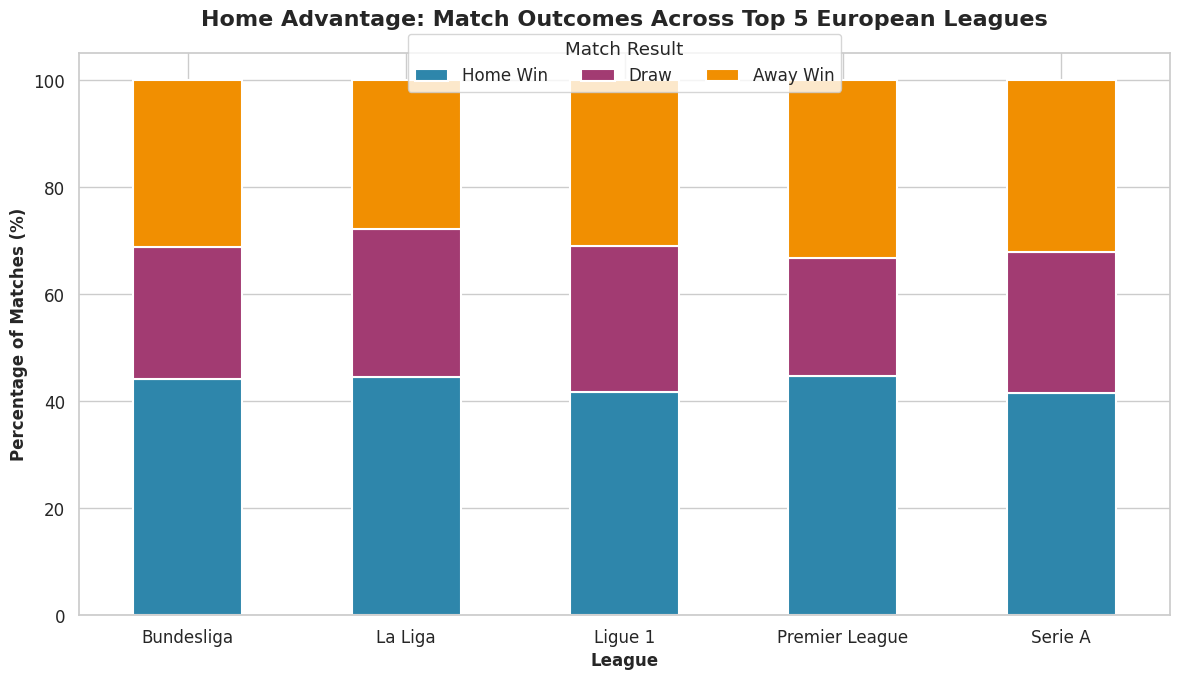

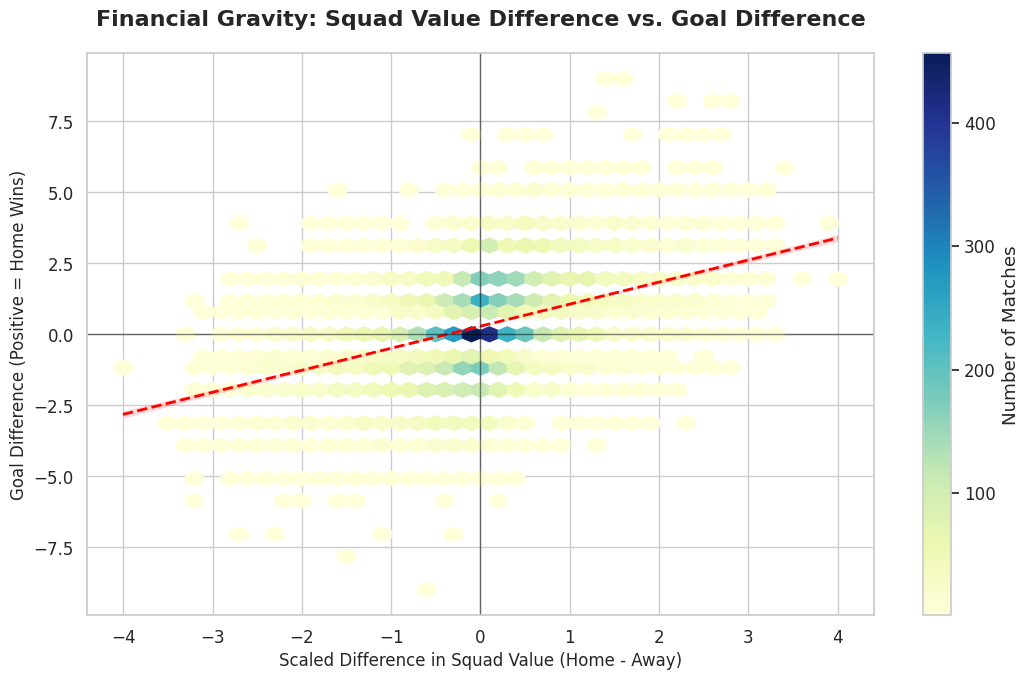

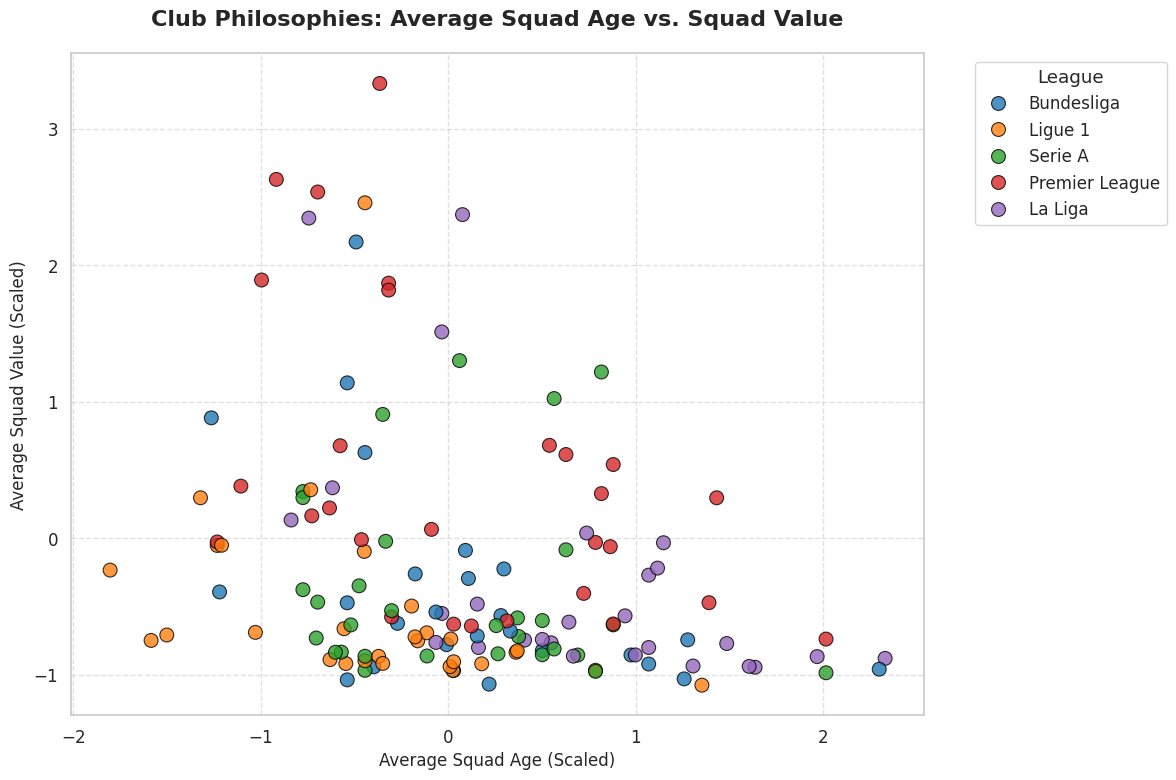

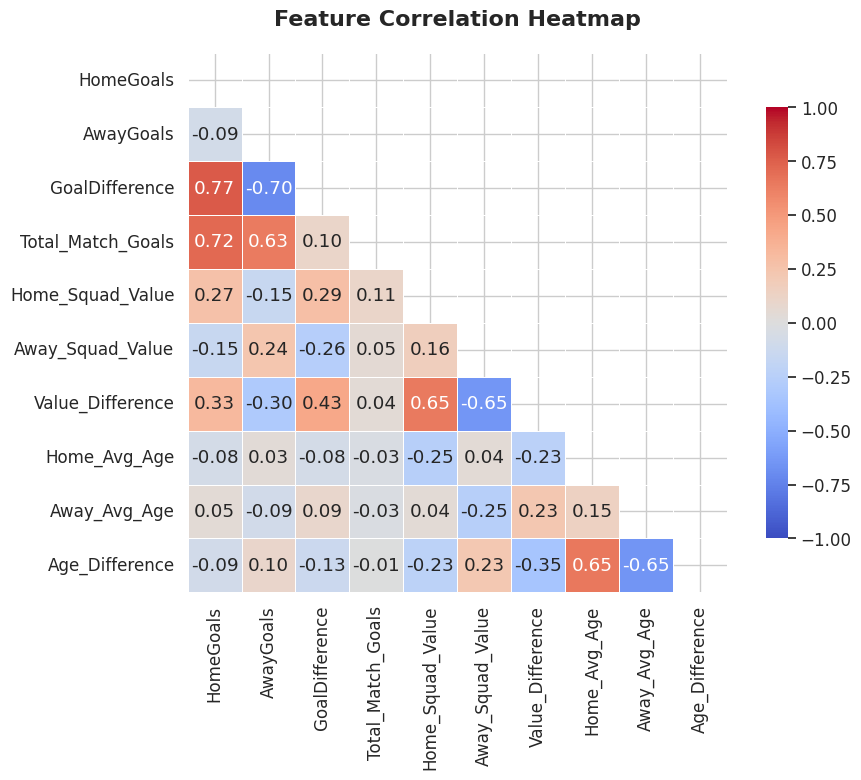

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load the dataset
try:
    df = pd.read_csv("Last Minute.csv")
except FileNotFoundError:
    print("Error: Dataset not found.")
    exit()

# Set a premium visual style for the presentation
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
palette_outcomes = {"H": "#2E86AB", "D": "#A23B72", "A": "#F18F01"} # Custom modern colors

# Create GoalDifference if it was dropped during transformations, or use existing
if "GoalDifference" not in df.columns:
    df["GoalDifference"] = df["HomeGoals"] - df["AwayGoals"]

# Reconstruct League column from One-Hot Encoding for visualizations
league_cols = [col for col in df.columns if col.startswith("League_")]
df["League_Name"] = df[league_cols].idxmax(axis=1).str.replace("League_", "")
# Handle the baseline dropped league (Bundesliga)
df.loc[df[league_cols].sum(axis=1) == 0, "League_Name"] = "Bundesliga"


# ==========================================
# PLOT 1: The "Home Fortress" Effect across Top 5 Leagues
# ==========================================
plt.figure(figsize=(12, 7))
outcome_counts = df.groupby(["League_Name", "Result"]).size().unstack()
outcome_percentages = outcome_counts.div(outcome_counts.sum(axis=1), axis=0) * 100

outcome_percentages[['H', 'D', 'A']].plot(
    kind='bar', stacked=True, figsize=(12, 7),
    color=[palette_outcomes['H'], palette_outcomes['D'], palette_outcomes['A']],
    edgecolor='white', linewidth=1.5
)

plt.title("Home Advantage: Match Outcomes Across Top 5 European Leagues", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("League", fontsize=12, fontweight='bold')
plt.ylabel("Percentage of Matches (%)", fontsize=12, fontweight='bold')
plt.legend(title="Match Result", labels=["Home Win", "Draw", "Away Win"], loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("Presentation_Plot_1_Home_Advantage.png", dpi=300)
plt.show()


# ==========================================
# PLOT 2: Financial Gravity (Does Money Buy Happiness?)
# ==========================================
plt.figure(figsize=(11, 7))
# Create a hexbin plot to show density where most matches occur
plt.hexbin(df['Value_Difference'], df['GoalDifference'], gridsize=40, cmap='YlGnBu', mincnt=1)
cb = plt.colorbar(label='Number of Matches')

# Add a trend line
sns.regplot(x='Value_Difference', y='GoalDifference', data=df, scatter=False, color='red', line_kws={"linewidth": 2, "linestyle": "--"})

plt.title("Financial Gravity: Squad Value Difference vs. Goal Difference", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Scaled Difference in Squad Value (Home - Away)", fontsize=12)
plt.ylabel("Goal Difference (Positive = Home Wins)", fontsize=12)
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.axvline(0, color='black', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig("Presentation_Plot_2_Financial_Gravity.png", dpi=300)
plt.show()


# ==========================================
# PLOT 3: The Age vs. Value Club Matrix
# ==========================================
plt.figure(figsize=(12, 8))
# We take average values per team to see club philosophies
team_profiles = df.groupby("HomeTeam").agg({
    "Home_Avg_Age": "mean",
    "Home_Squad_Value": "mean",
    "League_Name": "first"
}).reset_index()

sns.scatterplot(
    data=team_profiles, x="Home_Avg_Age", y="Home_Squad_Value",
    hue="League_Name", palette="tab10", s=100, alpha=0.8, edgecolor="black"
)

plt.title("Club Philosophies: Average Squad Age vs. Squad Value", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Average Squad Age (Scaled)", fontsize=12)
plt.ylabel("Average Squad Value (Scaled)", fontsize=12)
plt.legend(title="League", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("Presentation_Plot_3_Club_Profiles.png", dpi=300)
plt.show()


# ==========================================
# PLOT 4: Predictive Correlation Matrix
# ==========================================
plt.figure(figsize=(10, 8))
features_for_corr = [
    "HomeGoals", "AwayGoals", "GoalDifference", "Total_Match_Goals",
    "Home_Squad_Value", "Away_Squad_Value", "Value_Difference",
    "Home_Avg_Age", "Away_Avg_Age", "Age_Difference"
]

# Calculate correlation specifically against GoalDifference to see what drives wins
corr = df[features_for_corr].corr()

# Mask the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Feature Correlation Heatmap", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("Presentation_Plot_4_Correlation.png", dpi=300)
plt.show()


# 5. Hypothesis Testing & Time Series Analysis

Dataset loaded successfully.

--- Hypothesis Testing: Home Advantage ---
Null Hypothesis (H0): There is no significant difference between Home Goals and Away Goals.
Alternative Hypothesis (Ha): Home Goals are significantly greater than Away Goals.

Results:
Average Home Goals: 1.538
Average Away Goals: 1.250
T-statistic: 16.261
P-value (one-tailed): 4.769e-59

Conclusion: We REJECT the Null Hypothesis.
There is highly significant statistical evidence that teams score more goals at home.

--- Time Series Analysis: Win Rates Over Seasons ---


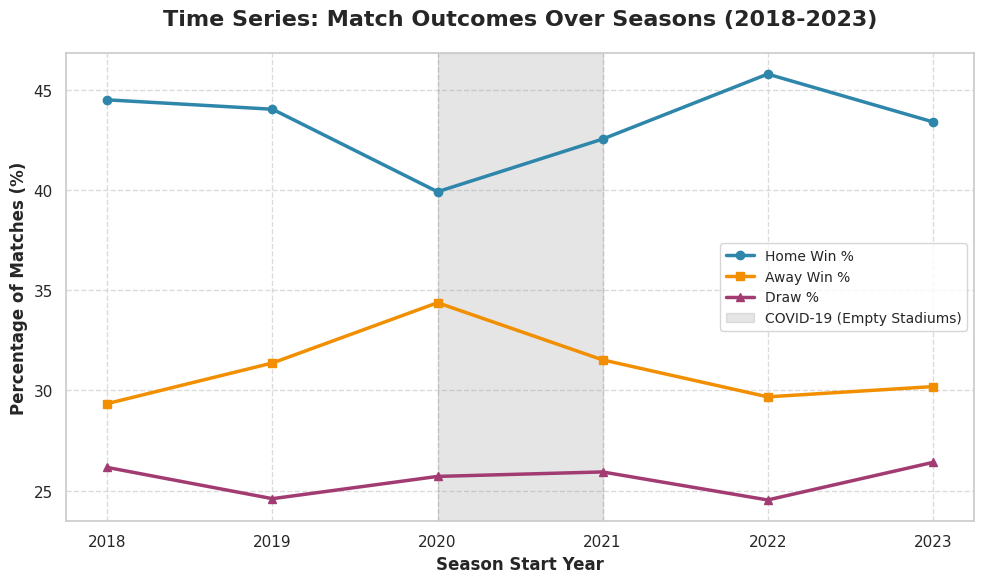

Complete. Time series plot saved as 'Time_Series_COVID_Impact.png'.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the dataset
try:
    df = pd.read_csv("Last Minute.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: Dataset not found. Please verify the filename.")
    exit()

# Set professional plotting style
sns.set_theme(style="whitegrid", context="notebook")

# ==========================================
# PART 1: Hypothesis Testing (Paired T-Test)
# ==========================================
print("\n--- Hypothesis Testing: Home Advantage ---")
print("Null Hypothesis (H0): There is no significant difference between Home Goals and Away Goals.")
print("Alternative Hypothesis (Ha): Home Goals are significantly greater than Away Goals.")

# We use a paired t-test because the goals are scored in the exact same match environment
home_goals = df['HomeGoals']
away_goals = df['AwayGoals']

t_stat, p_value = stats.ttest_rel(home_goals, away_goals)

# Since we are testing if Home > Away (one-tailed test), we divide the two-tailed p-value by 2
p_value_one_tailed = p_value / 2

print(f"\nResults:")
print(f"Average Home Goals: {home_goals.mean():.3f}")
print(f"Average Away Goals: {away_goals.mean():.3f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value (one-tailed): {p_value_one_tailed:.3e}")

alpha = 0.05
if p_value_one_tailed < alpha and t_stat > 0:
    print("\nConclusion: We REJECT the Null Hypothesis.")
    print("There is highly significant statistical evidence that teams score more goals at home.")
else:
    print("\nConclusion: We FAIL TO REJECT the Null Hypothesis.")
    print("There is no significant evidence of a home goal advantage.")


# ==========================================
# PART 2: Time Series Analysis (The COVID-19 Impact)
# ==========================================
print("\n--- Time Series Analysis: Win Rates Over Seasons ---")

# Calculate the percentage of Home Wins, Draws, and Away Wins per season
season_stats = df.groupby(['Season', 'Result']).size().unstack(fill_value=0)
season_totals = season_stats.sum(axis=1)

# Convert counts to percentages
season_percentages = (season_stats.divide(season_totals, axis=0) * 100).reset_index()

# Plotting the Time Series
plt.figure(figsize=(10, 6))

plt.plot(season_percentages['Season'], season_percentages['H'], marker='o', linewidth=2.5, color='#2E86AB', label='Home Win %')
plt.plot(season_percentages['Season'], season_percentages['A'], marker='s', linewidth=2.5, color='#F18F01', label='Away Win %')
plt.plot(season_percentages['Season'], season_percentages['D'], marker='^', linewidth=2.5, color='#A23B72', label='Draw %')

# Add a vertical span to highlight the COVID-19 pandemic seasons (largely empty stadiums)
plt.axvspan(2020, 2021, color='gray', alpha=0.2, label='COVID-19 (Empty Stadiums)')

plt.title("Time Series: Match Outcomes Over Seasons (2018-2023)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Season Start Year", fontsize=12, fontweight='bold')
plt.ylabel("Percentage of Matches (%)", fontsize=12, fontweight='bold')
plt.xticks(season_percentages['Season']) # Ensure all years are shown as integers
plt.legend(loc='best', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("Time_Series_COVID_Impact.png", dpi=300)
plt.show()

print("Complete. Time series plot saved as 'Time_Series_COVID_Impact.png'.")

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings

warnings.filterwarnings('ignore')

# 1. Загрузка датасета
try:
    df = pd.read_csv("Last Minute.csv")
    print(f"Dataset loaded successfully. Total matches for ML: {len(df)}")
except FileNotFoundError:
    print("Error: 'Last Minute.csv' not found. Please verify the filename.")
    exit()

# 2. Выбор признаков (Features) и целевой переменной (Target)
# Важно: берем только те данные, которые известны ДО стартового свистка!
features = [
    "Home_Squad_Value", "Away_Squad_Value", "Value_Difference",
    "Home_Avg_Age", "Away_Avg_Age", "Age_Difference"
]

# Добавляем названия лиг (One-Hot Encoded колонки)
league_cols = [col for col in df.columns if col.startswith("League_")]
features.extend(league_cols)

X = df[features]
y = df["Result_Encoded"]

# 3. Train/Test Split
print("\nSplitting dataset into 80% training and 20% testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {len(X_train)} matches")
print(f"Testing set: {len(X_test)} matches")

# 4. Построение и обучение модели
print("\nTraining Random Forest Classifier model...")
# Настроены базовые гиперпараметры для защиты от переобучения
model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 5. Оценка результатов модели (Evaluation)
print("\nEvaluating model performance...\n")
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"=======================================")
print(f"🎯 Overall Accuracy: {accuracy * 100:.2f}%")
print(f"=======================================\n")

print("Detailed Classification Report (Precision, Recall, F1-Score):")
# Выводим подробный отчет по классам
print(classification_report(y_test, y_pred, target_names=['Away Win', 'Draw', 'Home Win']))

# Бонус для отчета: Важность признаков
print("\nFeature Importance (Top 5):")
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print(importances.head(5).to_string(index=False))

Dataset loaded successfully. Total matches for ML: 10574

Splitting dataset into 80% training and 20% testing sets...
Training set: 8459 matches
Testing set: 2115 matches

Training Random Forest Classifier model...

Evaluating model performance...

🎯 Overall Accuracy: 49.79%

Detailed Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

    Away Win       0.53      0.52      0.53       681
        Draw       0.30      0.37      0.33       518
    Home Win       0.63      0.55      0.59       916

    accuracy                           0.50      2115
   macro avg       0.49      0.48      0.48      2115
weighted avg       0.52      0.50      0.51      2115


Feature Importance (Top 5):
         Feature  Importance
Value_Difference    0.368547
Home_Squad_Value    0.185423
Away_Squad_Value    0.172394
  Age_Difference    0.088760
    Away_Avg_Age    0.075576
